# **((Modelling and Evaluating))**

## Objectives

* Answer Business Requirement: The client is interested in identifying non malignant and malignant skin cancer in patients through a machine learning application, used as a second opinion.

## Inputs

* inputs/skin_cancer_dataset/melanoma_cancer_dataset/train
* inputs/skin_cancer_dataset/melanoma_cancer_dataset/validation
* inputs/skin_cancer_dataset/melanoma_cancer_dataset/test

## Outputs

* outputs/v1/classification_report.txt
* outputs/v1/confusion_matrix.png
* outputs/v1/confusion_matrix.txt
* outputs/v1/roc_curve.png
* outputs/v1/melanoma_detector_model.keras

## Additional Comments

No additional comments

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/skin-lesion-detector/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'/workspaces/skin-lesion-detector'

---

# Data Directories

## Input Directories

Set train, validation, and test set paths so machine knows where the data is

In [5]:
my_data_dir = 'inputs/skin_cancer_dataset/melanoma_cancer_dataset'
train_path = my_data_dir + '/train'
validation_path = my_data_dir + '/validation'
test_path = my_data_dir + '/test'

## Output Directories

Set output directories so the machine knows where to place the outputs

In [6]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(current_dir) and version in os.listdir(current_dir + '/outputs'):
    print("outputs directory already exists")
    pass
else:
    os.makedirs(file_path)
    print("outputs directory created")

outputs directory already exists


# Set Label Names

Setting label names to know difference

In [7]:
labels = os.listdir(train_path)
print(f"Labels: {labels}")

Labels: ['malignant', 'benign']


# Image Augmentation

Here, we will augment image data. Image augmentation artificially expands your training dataset by creating modified copies of existing images, which helps Convolutional Neural Networks (CNNs) learn more generalized and resilient patterns. It also prevents overfitting. Since we have a dataset that has over 10k images, this dosent need to be excessive.

In [8]:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # This hides the GPU from Tensorflow(Yes, my GPU is bad. This called me poor in ways I did not know you could)

In [9]:
import tensorflow as tf

I0000 00:00:1788729972.823632   55874 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788729974.835703   55874 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788729980.012314   55874 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Importing ImageDataGenerator to be able to augment data. Then, we will initialize the image data generator

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmented_images = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode = 'nearest',
    brightness_range = [0.7, 1.2]
)

Now that we have defined what the image generator will do, we will apply it to the training data only(many mistakes were committed here)

Batch sizes for training data usually are in powers of 2

In [11]:
batch_size = 16
train_set = augmented_images.flow_from_directory(
    directory=train_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

train_set.class_indices

Found 7422 images belonging to 2 classes.


{'benign': 0, 'malignant': 1}

Now we do rescaling for both validation and test sets

In [12]:
validation_set = ImageDataGenerator(rescale=1.0/255.0).flow_from_directory(
    directory=validation_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

validation_set.class_indices

Found 1060 images belonging to 2 classes.


{'benign': 0, 'malignant': 1}

In [13]:
test_set = ImageDataGenerator(rescale=1.0/255.0).flow_from_directory(
    directory=test_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_set.class_indices

Found 2123 images belonging to 2 classes.


{'benign': 0, 'malignant': 1}

# Machine Learning Model

Import model packages

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense, Conv2D, MaxPooling2D
from tensorflow.keras import layers, regularizers, models
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [15]:
def create_model():
    model = models.Sequential([
        
        # First block
        layers.Conv2D(16, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4), input_shape=(224,224,3)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),

        #Second block
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer= regularizers.l2(5e-4)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        #Third blok
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        #last block
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # classifier footnote(?) I don't know its proper naming
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.5),

        layers.Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=1e-3)
    model.compile(loss='binary_crossentropy',
                  optimizer = optimizer,
                  metrics = ['accuracy'])
    return model


Lets have a look at the model summary

In [16]:
create_model().summary()

/home/cistudent/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788730006.005397   55874 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 65,697 (256.63 KB)

 Trainable params: 65,217 (254.75 KB)

 Non-trainable params: 480 (1.88 KB)

#### Model Overview

The model follows a VGG design, consisting of four conv. blocks that serve as feature encoders.
* Filter Growth: The number of filters double sequentially from 16 to 32, and then to 62 in the final two blocks. This allows the initial layers to capture low-level features such as angles, edges, color gradients, and texture, while thehigher-level layers look for asymmetry and border irregularities.
* Spatial Downsampling: Each convolutional block is followed by a (2, 2) MaxPooling layer. This reduces the spatial dimensions from 224x224 to 14x14, increasing the receptie field of neurons without increasing parameters

##### Classifier Head
Instead of a traditional flatten layer, the model uses Global Average Pooling. This reduces total parameter count, eliminates the need for weights(apart from mostly balanced dataset), and forces the feature maps in the final conv. layer to act as class activation maps.

##### Training Config.
The model is compiled for binary classification using the Adam optimizer with a standard learning rate of 1x10^-3, which balances fast initial convergence with stable weight updates. The Binary Crossentropy function is appropiate for reproducing proabilistic outputs with the sigmoid activation.

##### Summary
In summary, the architecture of the CNN model sacrifices extreme depth for efficient regularization, prioritizing validation performance over pure training accuracy. By combining agressive regularization(Dropout + l2) with normalizing layers(BatchNorm) and parameter reduction techniques, it is specifically tuned to prevent memorization and do well when distinguishing skin lesions from benign mimics

---

Well, this is going to take a while to learn. Next, we make sure early stopping is active

In [17]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

And now, we fit the model

In [ ]:
model = create_model()
model.fit(train_set,
          epochs=50,
          steps_per_epoch= len(train_set),
          validation_data=validation_set,
          validation_steps= len(validation_set),
          callbacks=[early_stop, reduce_lr],
          verbose=1
          )

Here we will plot the loss and accuracy plots. This was plotted when the model was run. This was the code used to plot and save the figures

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

losses = pd.DataFrame(model.history.history)

sns.set_style("whitegrid")
losses[['loss', 'val_loss']].plot(style='.-')
plt.title("Loss")
plt.savefig(f'{file_path}/model_training_losses.png',
            bbox_inches='tight', dpi=150)
plt.show()

print("\n")
losses[['accuracy', 'val_accuracy']].plot(style='.-')
plt.title("Accuracy")
plt.savefig(f'{file_path}/model_training_acc.png',
            bbox_inches='tight', dpi=150)
plt.show()

AttributeError: 'Sequential' object has no attribute 'history'

Save the model

In [ ]:
model.save(f'{file_path}/melanoma_detector_model.keras')

# Metrics

Here, we will view the metrics of the ML model

Lets evaluate the test set

In [18]:
import numpy as np
model = tf.keras.models.load_model(f'{file_path}/melanoma_detector_model.keras')


print("\n===== Evaluating on Test Set =====")
loss, accuracy = model.evaluate(test_set, steps=len(test_set), verbose=1)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

# Get predictions on test set
predictions = model.predict(test_set)
# Convert probabilities to binary classes (threshold 0.5)
predicted_classes = (predictions > 0.5).astype(int)



===== Evaluating on Test Set =====


I0000 00:00:1788730014.741935   55874 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
W0000 00:00:1788730015.419148   67351 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1788730015.713170   67351 cpu_allocator_impl.cc:82] Allocation of 25690112 exceeds 10% of free system memory.


  1/133 ━━━━━━━━━━━━━━━━━━━━ 2:45 1s/step - accuracy: 1.0000 - loss: 0.0766

W0000 00:00:1788730015.952553   67350 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.


  2/133 ━━━━━━━━━━━━━━━━━━━━ 53s 405ms/step - accuracy: 1.0000 - loss: 0.0826

W0000 00:00:1788730016.159963   67350 cpu_allocator_impl.cc:82] Allocation of 25690112 exceeds 10% of free system memory.
W0000 00:00:1788730016.333350   67350 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.


133/133 ━━━━━━━━━━━━━━━━━━━━ 33s 240ms/step - accuracy: 0.8055 - loss: 0.4858
Test Accuracy: 0.8055
Test Loss: 0.4858
133/133 ━━━━━━━━━━━━━━━━━━━━ 32s 239ms/step


# True Labels/Importing

In [19]:
true_classes = test_set.classes
class_names = ['benign', 'malignant'] # this returns benign or malignant

In [20]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

## Lets see the Classification Report

In [21]:
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(true_classes, predicted_classes, target_names=class_names))

classification_report = classification_report(true_classes, predicted_classes, target_names=class_names)

with open(f'{file_path}/classification_report.txt', 'w') as f:
    f.write(classification_report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      benign       0.73      0.99      0.84      1101
   malignant       0.98      0.61      0.75      1022

    accuracy                           0.81      2123
   macro avg       0.85      0.80      0.80      2123
weighted avg       0.85      0.81      0.80      2123



* Meets most of the criteria for the performance goals listed in the README

## The Confusion Matrix

In [22]:
conf_mat = confusion_matrix(true_classes, predicted_classes)

output_str = '\n' + '='*50 + '\n'
output_str += "Confusion Matrix\n"
output_str += "="*50 + "\n"
output_str += f"                     Predicted\n"
output_str += f"                {class_names[0]}    {class_names[1]}\n"
output_str += f"Actual {class_names[0]}    |  {conf_mat[0,0]:<5}    {conf_mat[0,1]:<5}\n"
output_str += f"Actual {class_names[1]} |  {conf_mat[1,0]:<5}    {conf_mat[1,1]:<5}\n"

# Save the pretty formatted string to file
with open(f'{file_path}/confusion_matrix.txt', 'w') as f:
    f.write(output_str)

print('\n' + '='*50)
print("Confusion Matrix")
print("="*50)
print(f"                     Predicted")
print(f"                {class_names[0]}    {class_names[1]}")
print(f"Actual {class_names[0]}    |  {conf_mat[0,0]:<5}    {conf_mat[0,1]:<5}")
print(f"Actual {class_names[1]} |  {conf_mat[1,0]:<5}    {conf_mat[1,1]:<5}")


Confusion Matrix
                     Predicted
                benign    malignant
Actual benign    |  1085     16   
Actual malignant |  397      625  


# Heatmap of Confusion Matrix

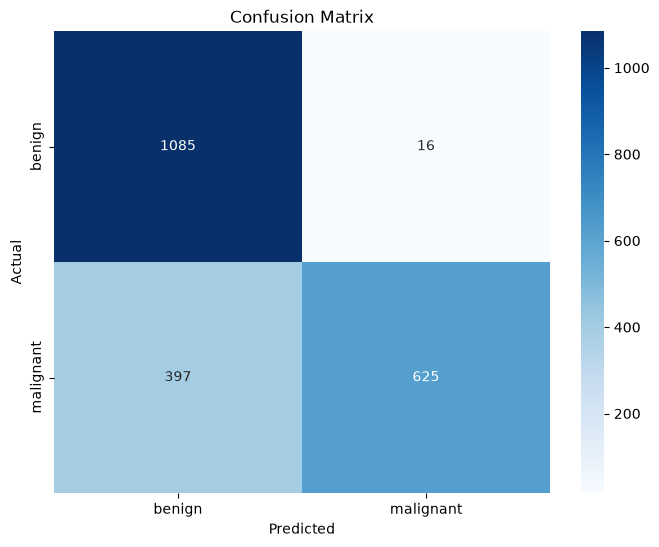

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f'{file_path}/confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# ROC Curve Plot

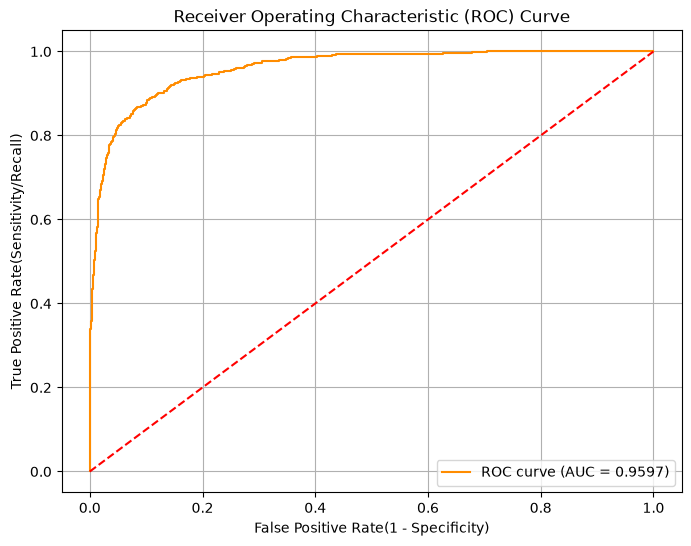

In [26]:
fpr, tpr, thresholds = roc_curve(true_classes, predictions)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc_score(true_classes, predictions):.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate(1 - Specificity)')
plt.ylabel('True Positive Rate(Sensitivity/Recall)')
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(f'{file_path}/roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()


---

# Predicting on new Data

load random image

Image from malignant class at index 32:


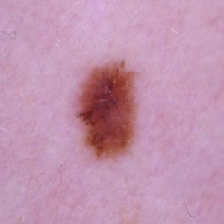

In [39]:
from tensorflow.keras.preprocessing import image

pointer = 32
label = labels[0] 
pil_image = image.load_img(f"{train_path}/{label}/{os.listdir(f'{train_path}/{label}')[pointer]}", target_size=(224, 224))

print(f"Image from {label} class at index {pointer}:")
pil_image

convert image into an array and prepare for prediction

In [40]:
my_image = image.img_to_array(pil_image)
my_image = np.expand_dims(my_image, axis=0)/255.0  # Add batch dimension and normalize
print(f"Shape of the image array: {my_image.shape}")

Shape of the image array: (1, 224, 224, 3)


Now its time to predict

In [41]:
prediction_probablility = model.predict(my_image)[0, 0]

target_map = {v: k for k, v in train_set.class_indices.items()}
predicted_class = target_map[int(prediction_probablility > 0.5)]
if prediction_probablility > 0.5:
    print(f"The model predicts this image is {predicted_class} with a probability of {prediction_probablility:.4f}")
else:
    print(f"The model predicts this image is {predicted_class} with a probability of {1 - prediction_probablility:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
The model predicts this image is benign with a probability of 0.9175
